In [ ]:
# Chargement des donnees (a ne lancer qu'une fois par session de kernel)
from ml.mae_reconstruction import (load_mae_and_data, plot_object_windows,
                                   export_reconstructions, reconstruction_scores)

CKPT = '2026-08-30_17-25-18'   # run 200 epochs
mae, cfg, stats, per_obj, feature_cols = load_mae_and_data(ckpt_id=CKPT)
print(len(per_obj), 'objets |', feature_cols)

In [ ]:
# Plot interactif (relancer autant que voulu, sans recharger les donnees)
plot_object_windows(mae, cfg, stats, per_obj, feature_cols,
                    norad=64685, n_windows=3, to_plot=['sma', 'sma_diff'])

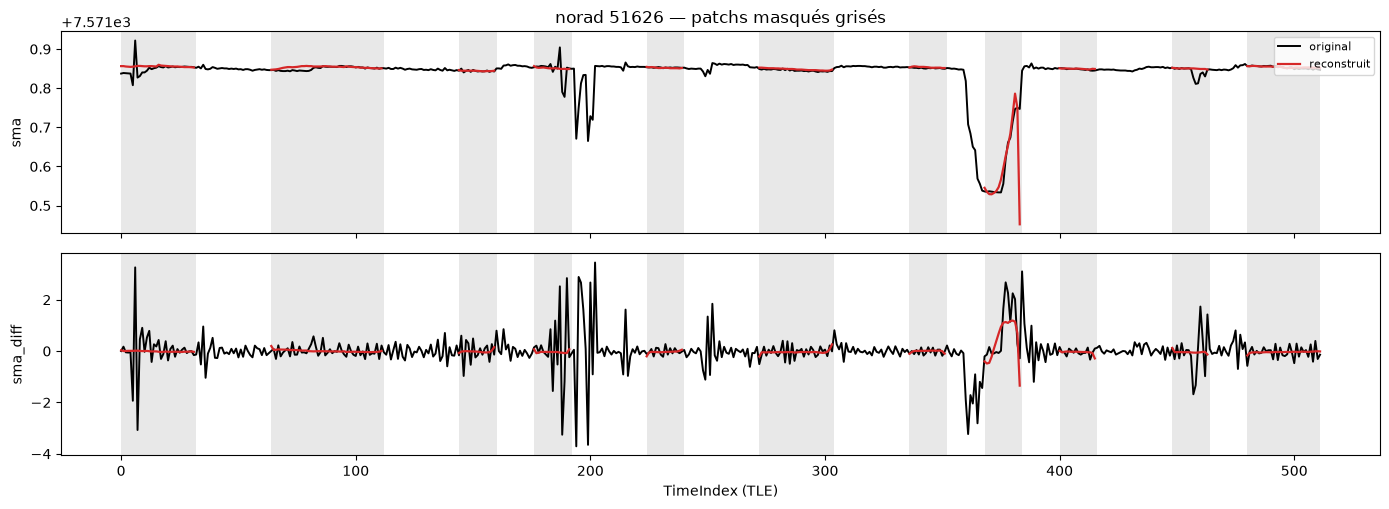

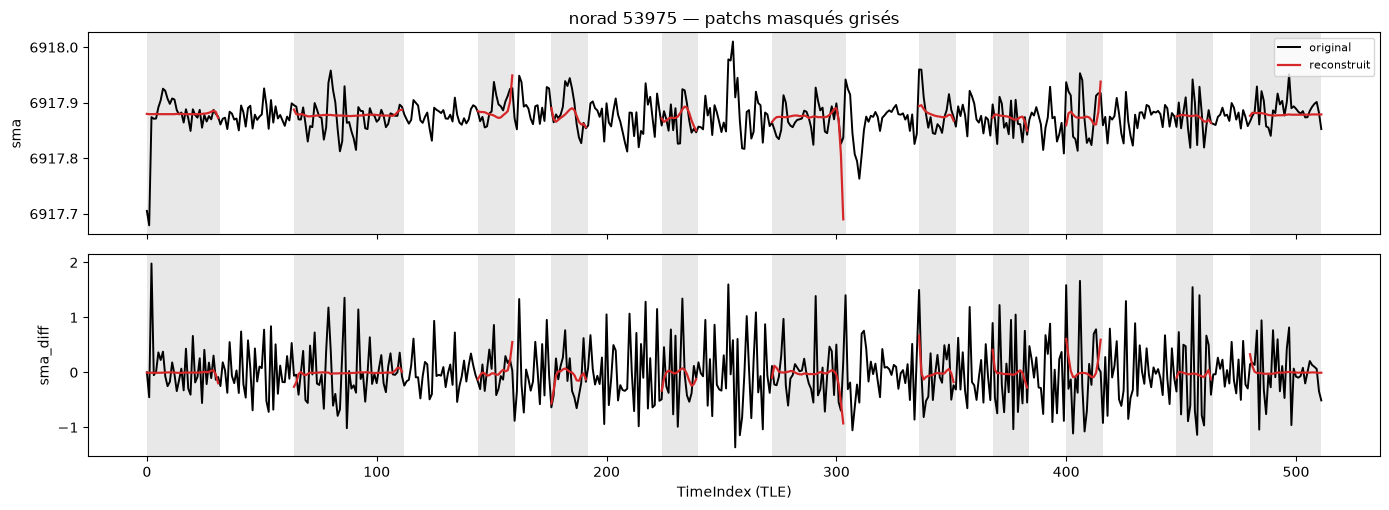

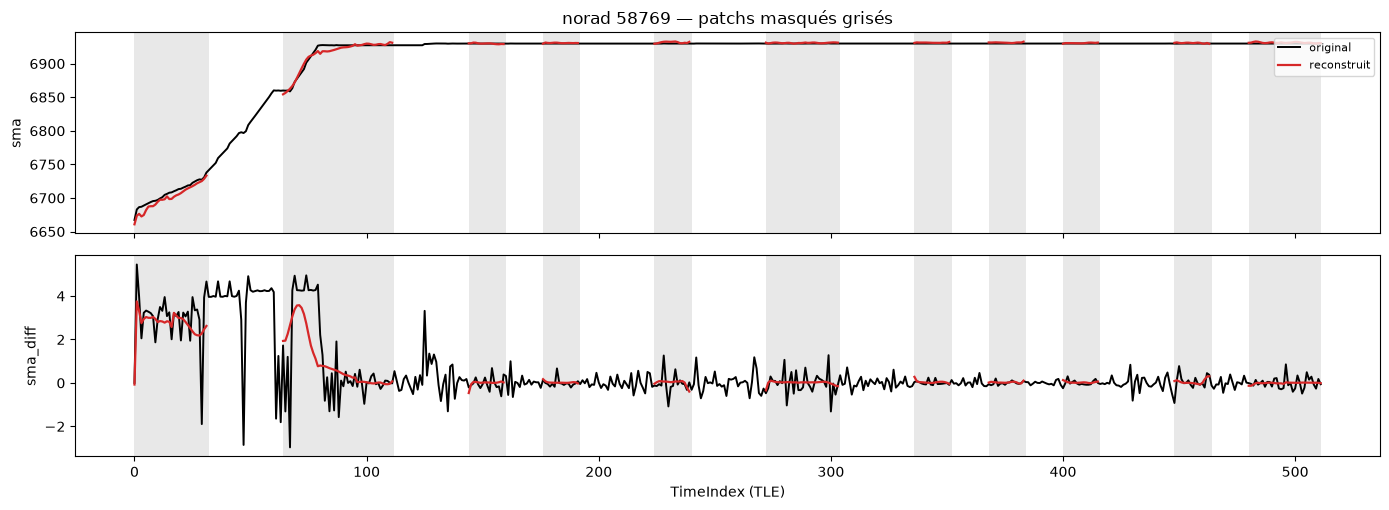

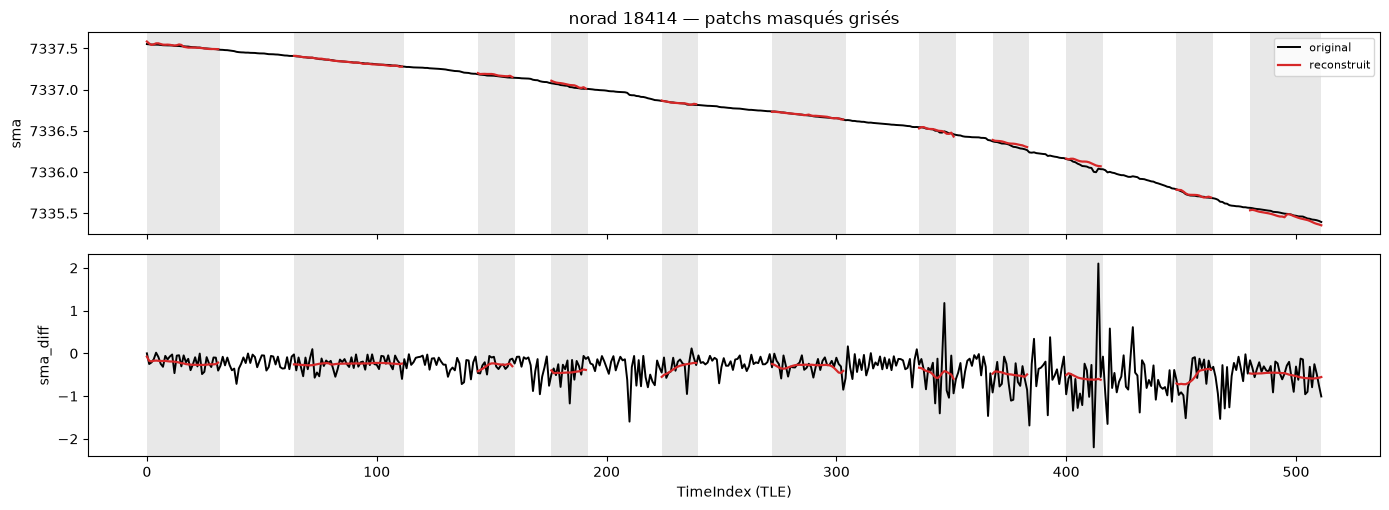

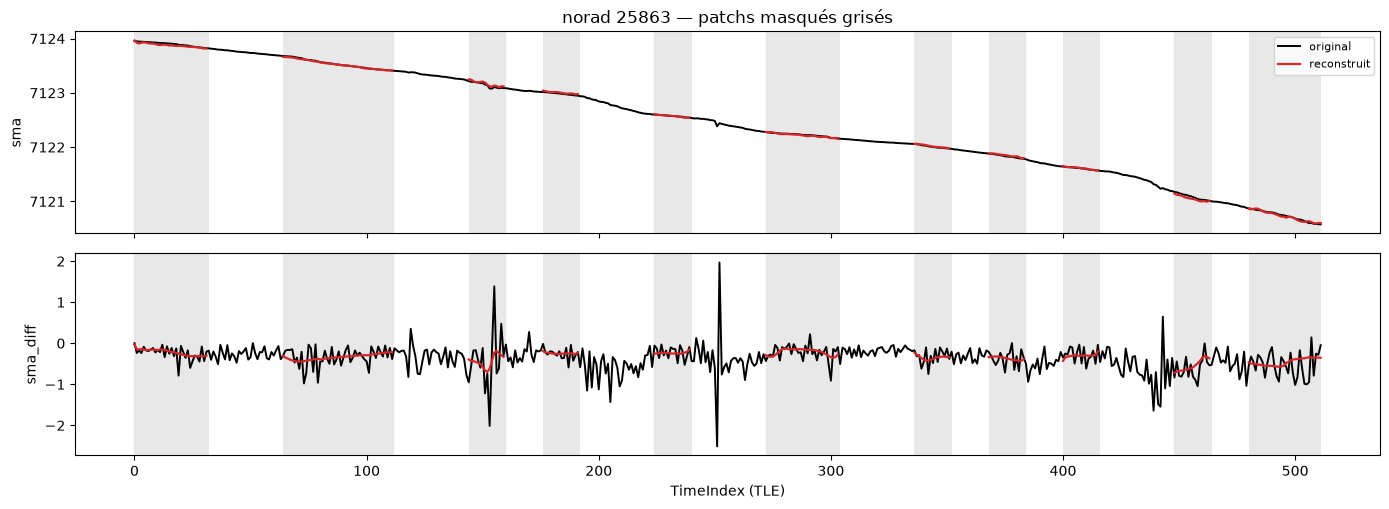

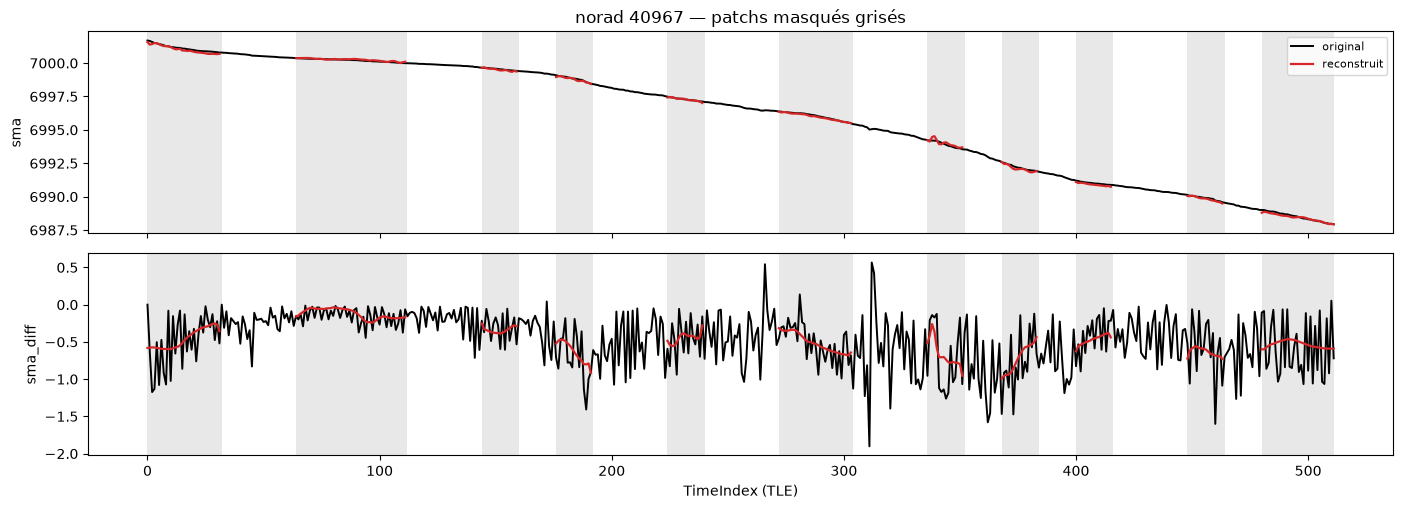

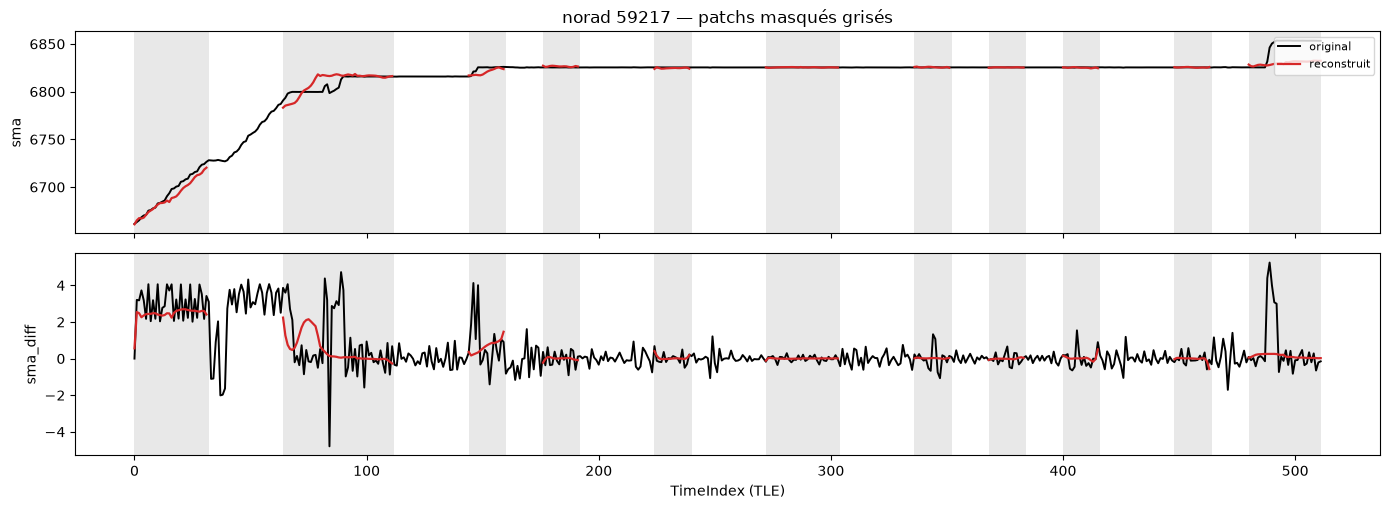

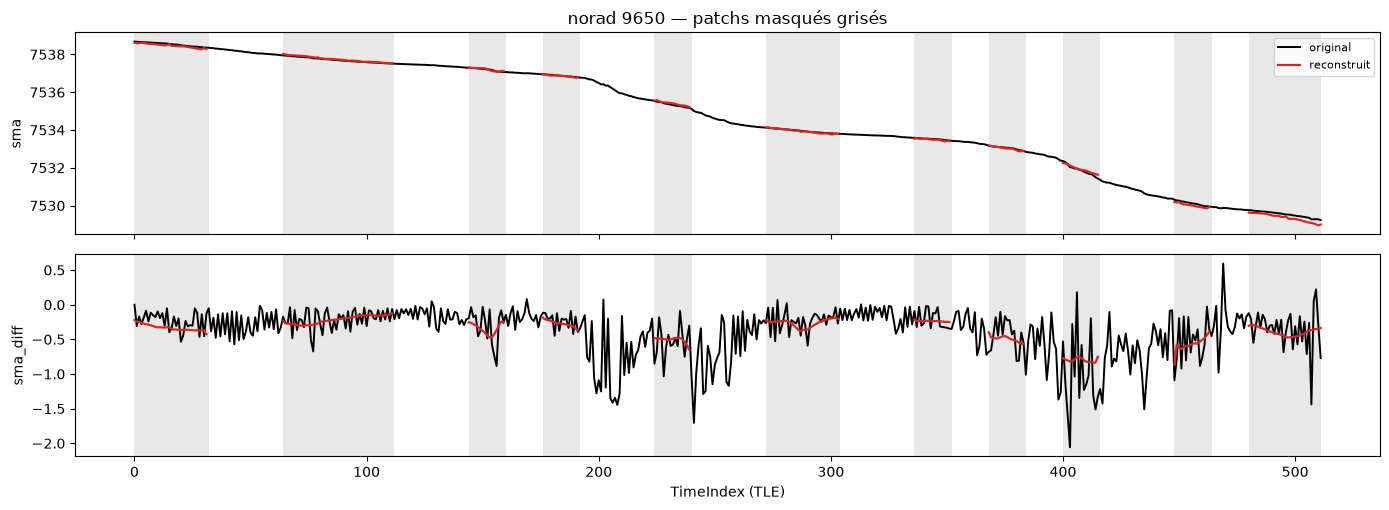

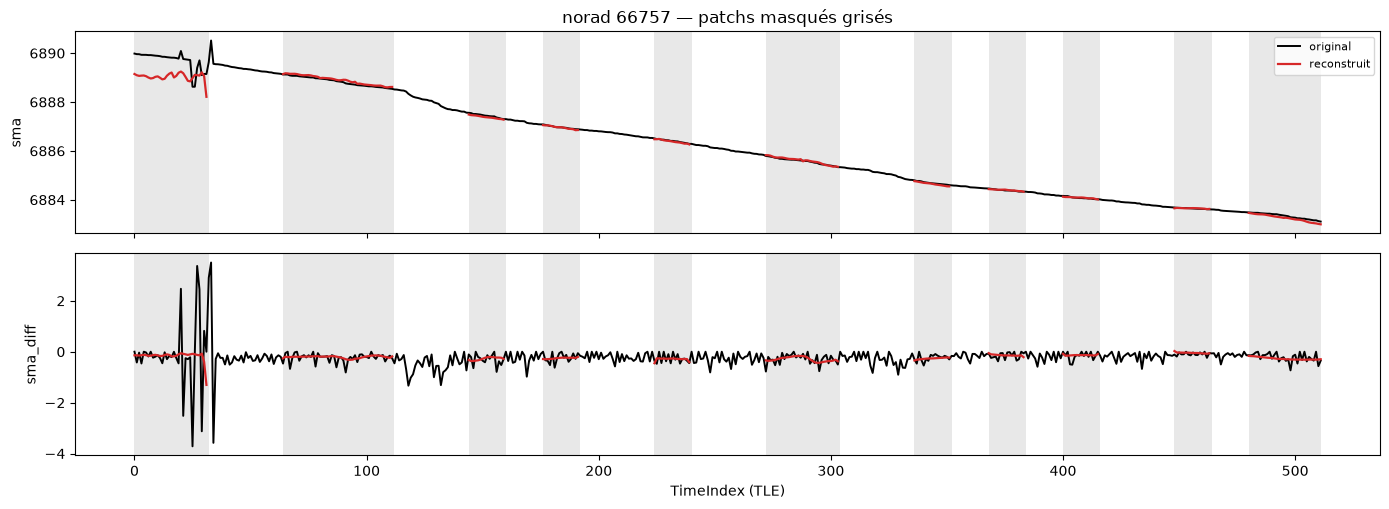

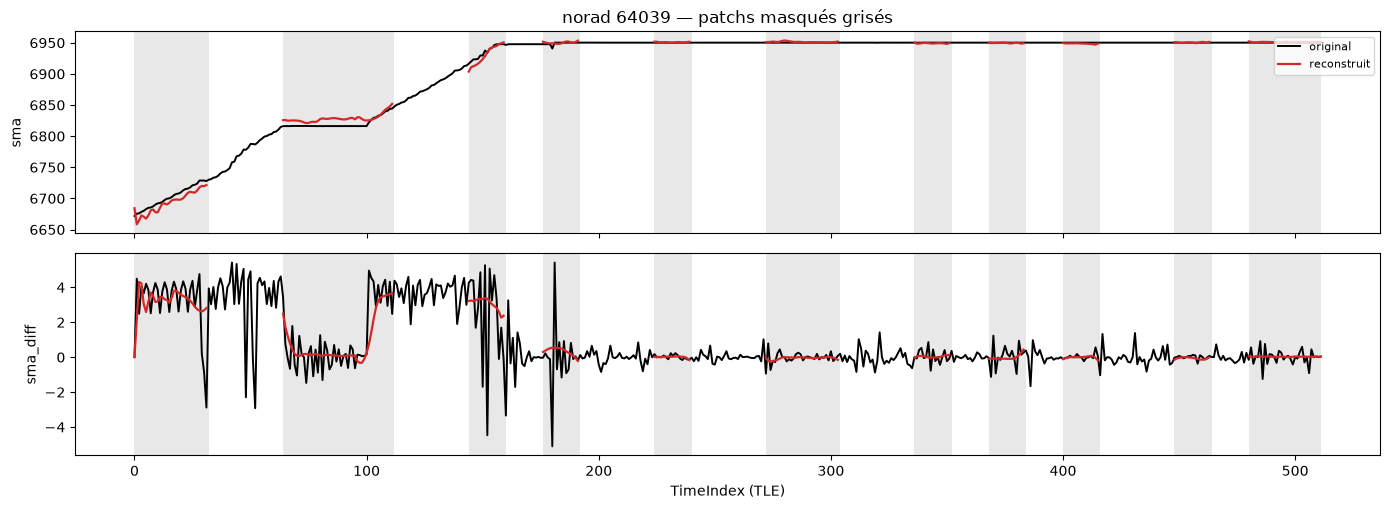

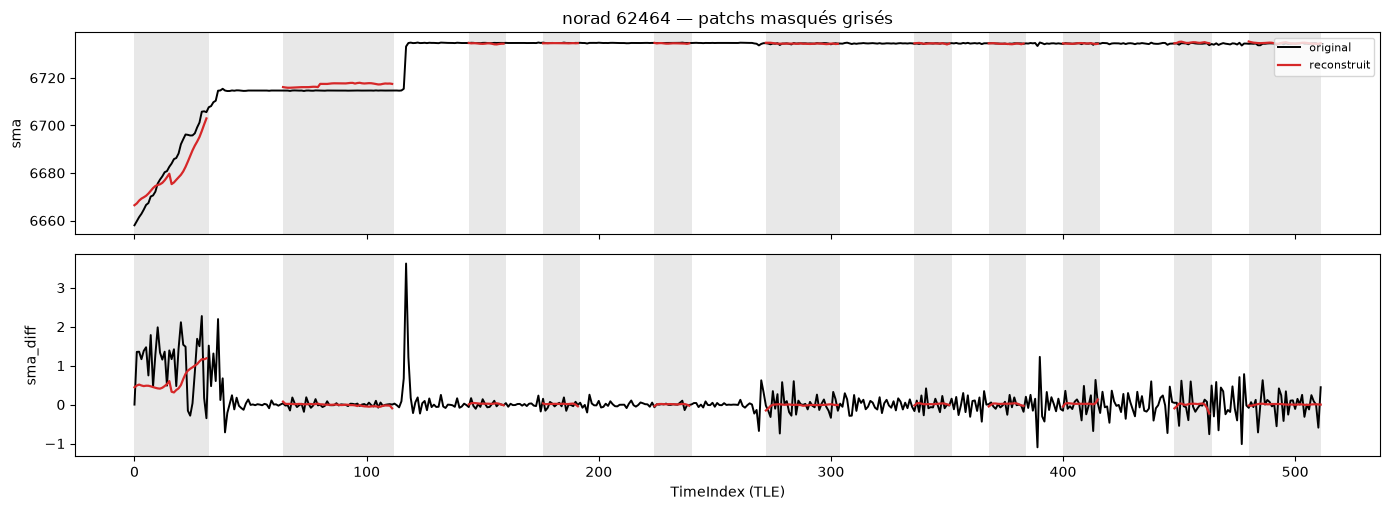

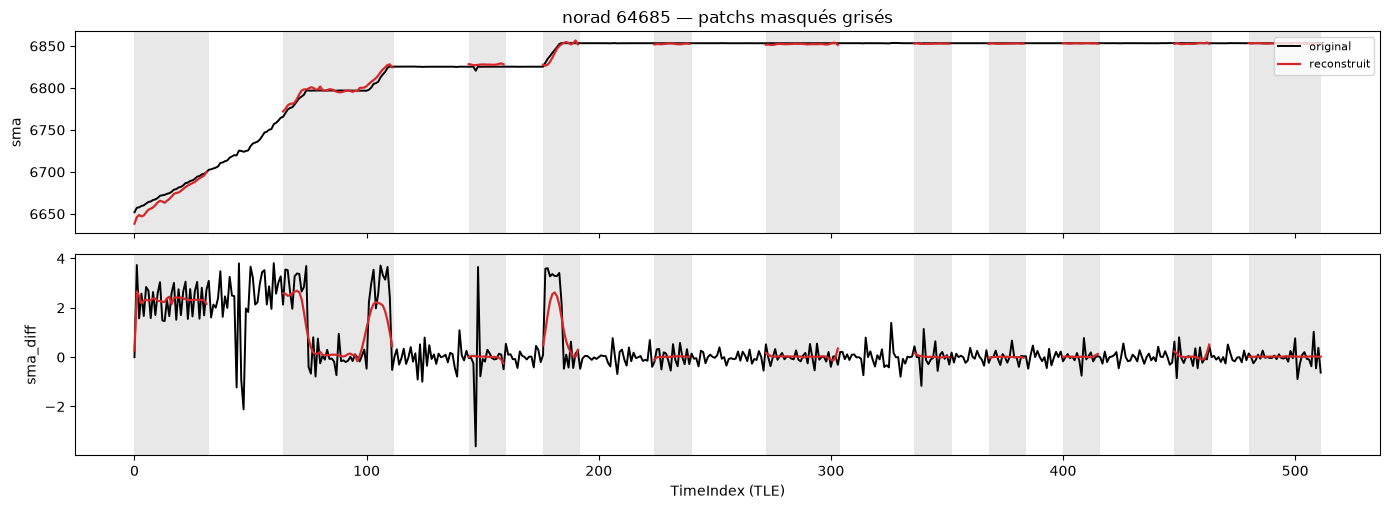

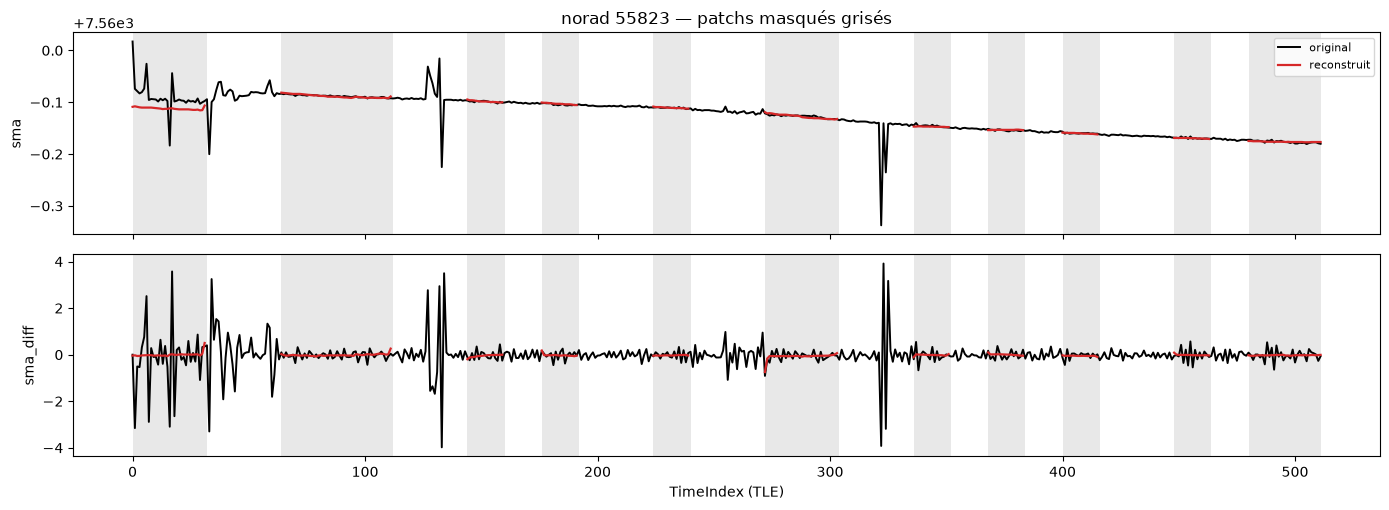

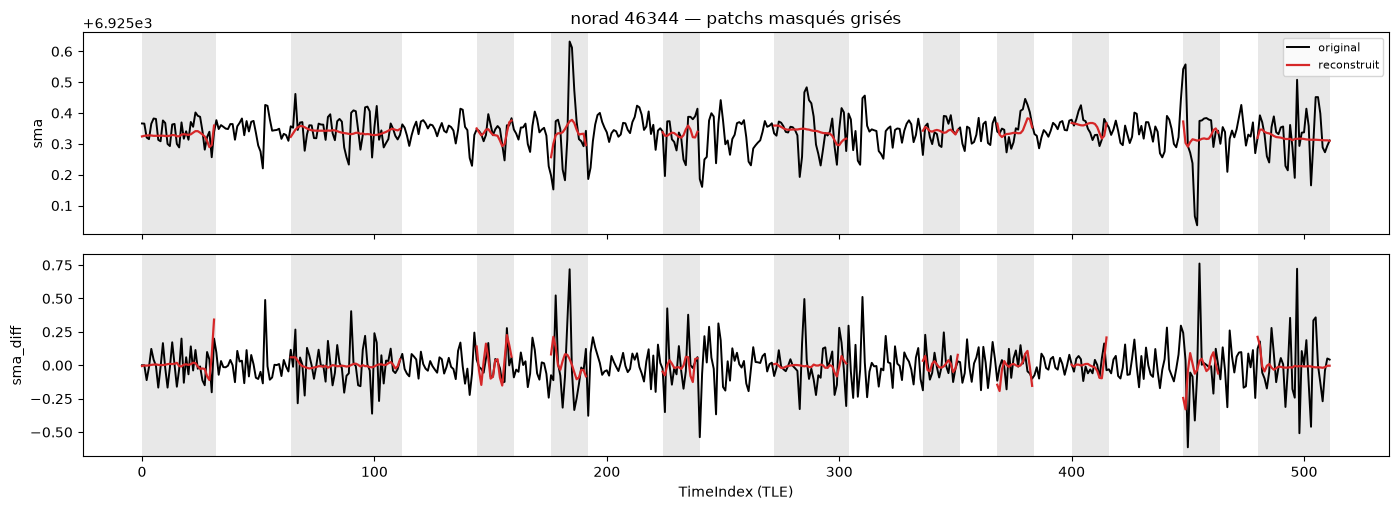

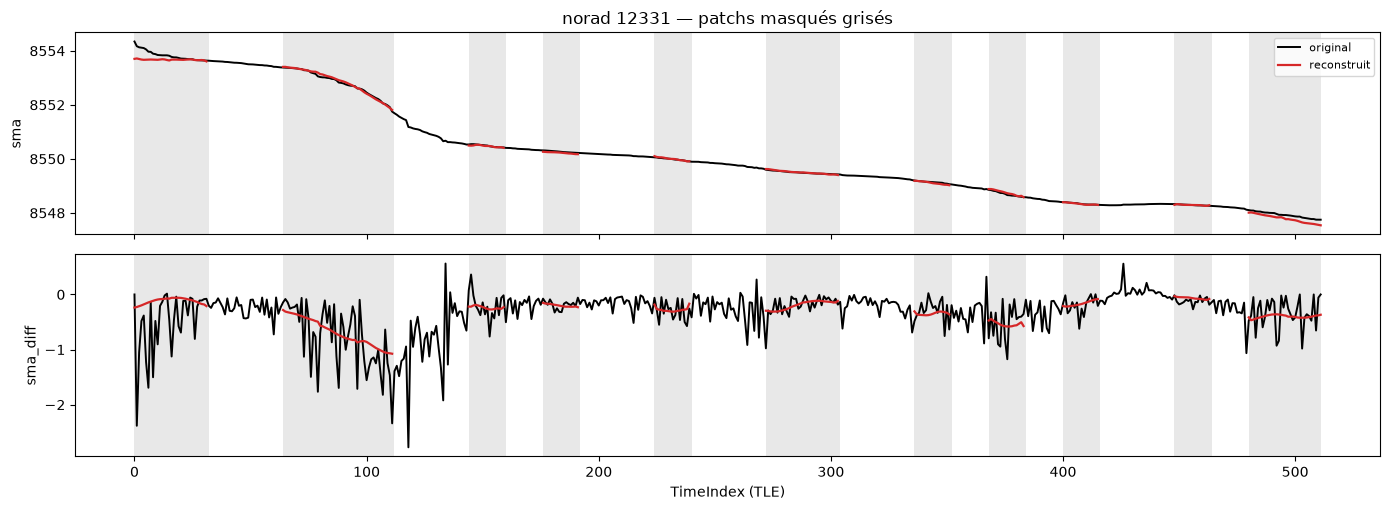

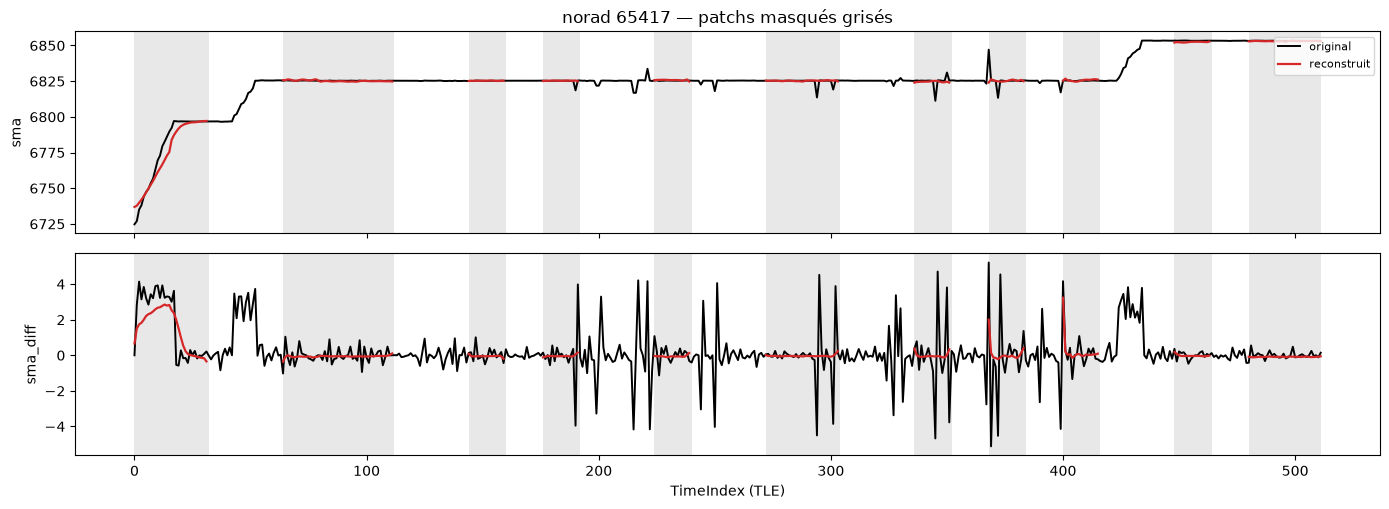

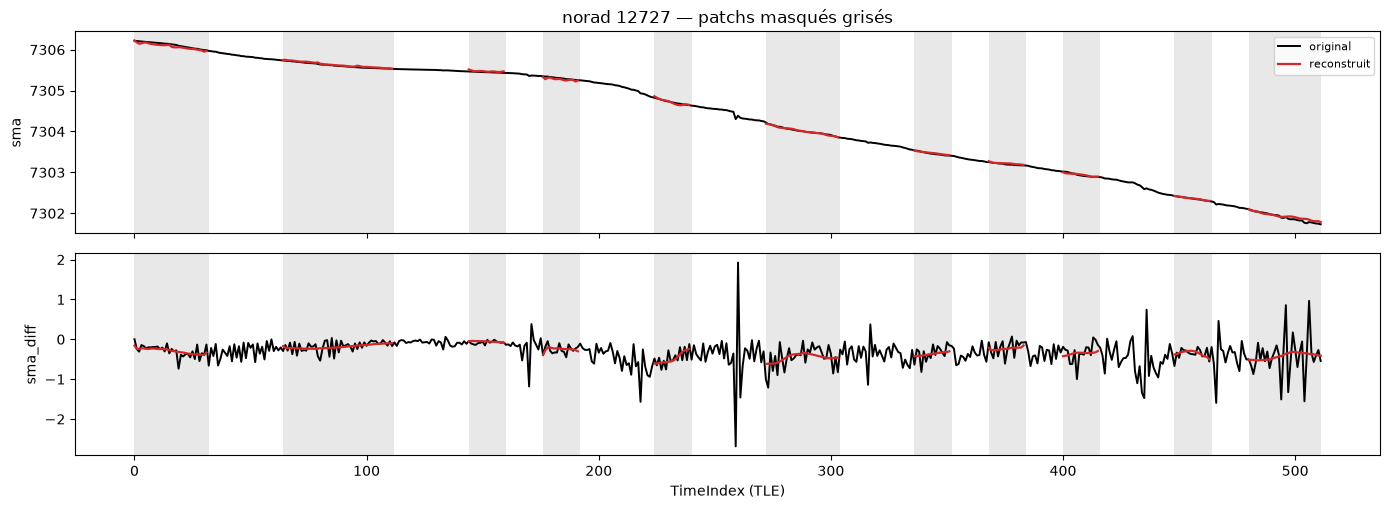

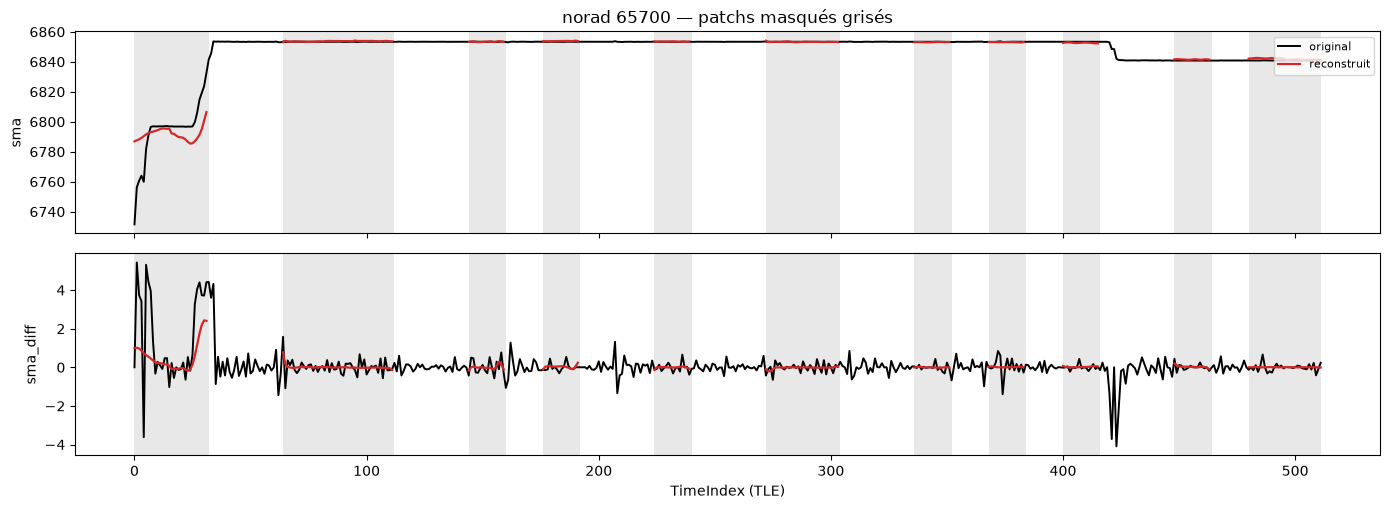

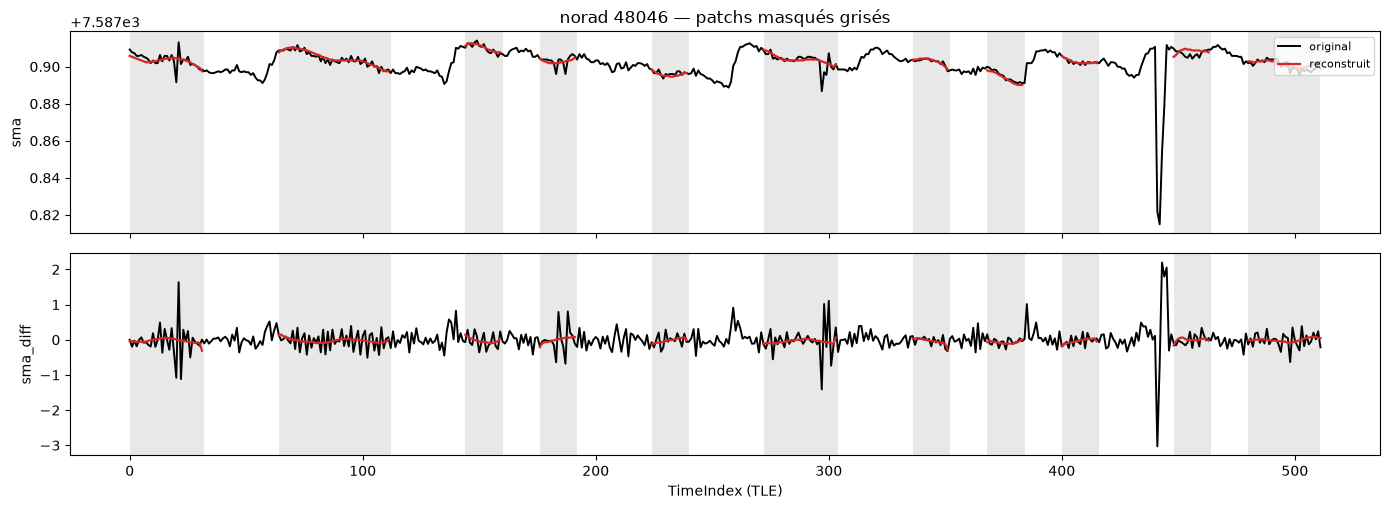

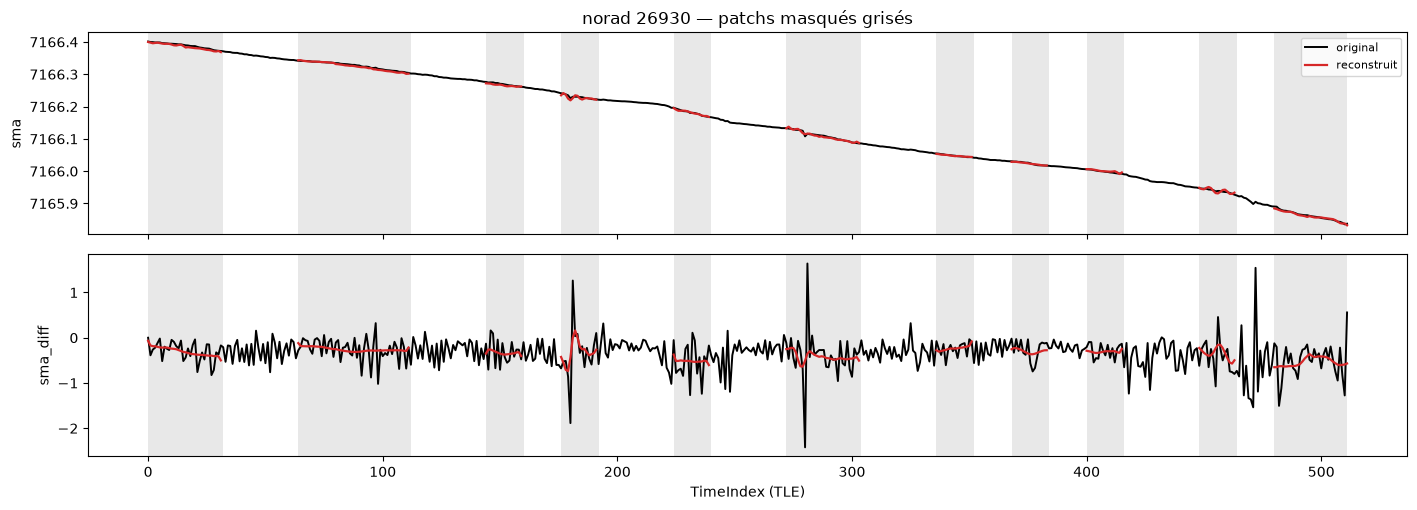

In [4]:
import random 
for norad in random.sample(list(per_obj.keys()), 20):
    plot_object_windows(mae,cfg,stats,per_obj,feature_cols, norad=norad, n_windows=1, to_plot=['sma', 'sma_diff'])

In [ ]:
# Export en lot des figures de reconstruction
#   outputs/mae_reconstruction/                    -> ~100 objets tires au hasard
#   outputs/mae_reconstruction/best_reconstructions/ -> les meilleures reconstructions
# Le classement des "meilleures" exige au moins min_evenements pics de sma_diff : sans ce
# filtre il remonterait des objets plats, triviaux a reconstruire et sans interet.
import numpy as np, torch
from pathlib import Path
import ml.mae_reconstruction as _mr

mae = mae.to('cuda' if torch.cuda.is_available() else 'cpu')
# racine du repo deduite du module, pas du cwd : un kernel peut demarrer n'importe ou
OUT = Path(_mr.__file__).resolve().parents[2] / 'outputs' / 'mae_reconstruction'

# classer tous les objets serait long : on tire un vivier de candidats
rng = np.random.default_rng(0)
eligibles = [n for n, X in per_obj.items() if len(X) >= cfg.data.window_size]
candidats = list(rng.choice(eligibles, size=min(3000, len(eligibles)), replace=False))

scores, meilleurs = export_reconstructions(
    mae, cfg, stats, per_obj, feature_cols, out_dir=OUT,
    n_representatifs=100, n_meilleurs=10, n_windows=1,
    cols=('sma', 'sma_diff'), min_evenements=5,
    candidats=candidats, toujours_inclure=(64685,),
)
meilleurs

In [ ]:
# Clusters de constellations : un sous-dossier de figures par cluster
#   outputs/mae_reconstruction/clusters/<rang>_<famille>_n<taille>/
# Representations = token CLS de l'encodeur pre-entraine, moyenne sur les fenetres,
# puis HDBSCAN. Les figures sont les objets les plus proches du centroide du cluster.
from ml.mae_reconstruction import export_clusters

clusters, appartenance = export_clusters(
    mae, cfg, stats, per_obj, feature_cols,
    out_dir=OUT / 'clusters',
    n_objets=6000, stride=256,
    min_cluster_size=25, min_samples=10,
    n_figures=8, n_clusters_max=15,
    cols=('sma', 'sma_diff'),
)
clusters